# 04 Normalisation, Weighting & DPI Construction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

In [2]:
PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR    = Path('../outputs')

df = pd.read_csv(PROCESSED_DIR / 'driver_season_clustered.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

Shape: (105, 19)

Columns: ['season', 'driver_id', 'driver_code', 'driver_name', 'constructor', 'races', 'total_points', 'points_per_race', 'avg_finish_position', 'finish_position_std', 'wins', 'podiums', 'dnfs', 'dnf_rate', 'avg_positions_gained', 'points_finish_rate', 'avg_quali_position', 'cluster', 'cluster_label']


## Normalisation

MinMax normalisation is applied to bring all features to a 0-1 scale 
so they can be combined into a single index. Before scaling, four features 
are inverted because a lower value represents better performance. Without 
this step, a driver with a high DNF rate would score well on that feature 
when in reality it represents poor reliability.

| Feature | Why inverted |
|---|---|
| avg_finish_position | Position 1 is best - lower number is better |
| avg_quali_position | Position 1 is best - lower number is better |
| dnf_rate | Fewer retirements is better |
| finish_position_std | Lower variance means more consistent performance |

In [4]:
index_features = [
    'points_per_race',
    'avg_finish_position',
    'finish_position_std',
    'wins',
    'podiums',
    'points_finish_rate',
    'dnf_rate',
    'avg_positions_gained',
    'avg_quali_position'
]

norm_df = df.copy()

for col in ['avg_finish_position', 'avg_quali_position',
            'dnf_rate', 'finish_position_std']:
    norm_df[col] = -norm_df[col]

scaler = MinMaxScaler()
norm_df[index_features] = scaler.fit_transform(norm_df[index_features])

print("Normalised feature ranges:")
print(norm_df[index_features].describe().loc[['min', 'max']].round(3))

Normalised feature ranges:
     points_per_race  avg_finish_position  finish_position_std  wins  podiums  \
min              0.0                  0.0                  0.0   0.0      0.0   
max              1.0                  1.0                  1.0   1.0      1.0   

     points_finish_rate  dnf_rate  avg_positions_gained  avg_quali_position  
min                 0.0       0.0                   0.0                 0.0  
max                 1.0       1.0                   1.0                 1.0  


## Weighting and DPI Construction

In [7]:
weight = 1 / len(index_features)
norm_df['DPI'] = norm_df[index_features].sum(axis=1) * weight

norm_df['DPI_rank'] = norm_df['DPI'].rank(
    ascending=False, method='dense').astype(int)

print(f"Equal weight applied: {weight:.4f} per feature")
print(f"\nDPI score range: {norm_df['DPI'].min():.3f} - {norm_df['DPI'].max():.3f}")
print("\nTop 10 driver-seasons by DPI:")
print(
    norm_df.sort_values('DPI', ascending=False)
    [['driver_name', 'season', 'DPI', 'DPI_rank']]
    .head(10)
    .to_string(index=False)
)

Equal weight applied: 0.1111 per feature

DPI score range: 0.161 - 0.970

Top 10 driver-seasons by DPI:
    driver_name  season      DPI  DPI_rank
 Max Verstappen    2023 0.969559         1
 Max Verstappen    2022 0.763918         2
 Lewis Hamilton    2021 0.733471         3
 Max Verstappen    2024 0.731331         4
 Max Verstappen    2025 0.723557         5
 Max Verstappen    2021 0.679288         6
  Oscar Piastri    2025 0.670320         7
   Lando Norris    2025 0.665965         8
   Lando Norris    2024 0.659897         9
Charles Leclerc    2024 0.650224        10


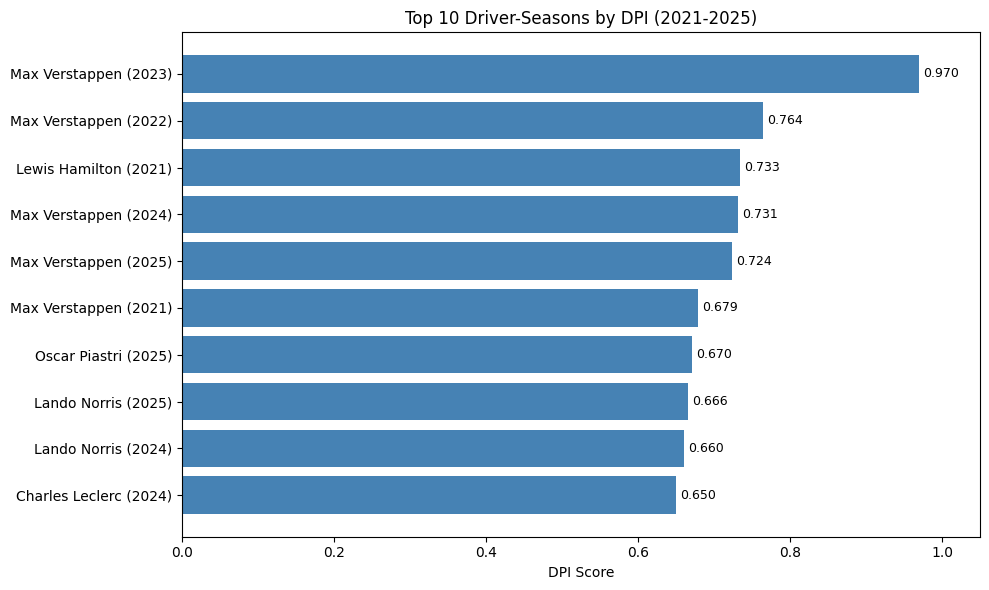

In [8]:
top10 = norm_df.sort_values('DPI', ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top10['driver_name'] + ' (' + top10['season'].astype(str) + ')',
    top10['DPI'],
    color='steelblue'
)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
plt.title('Top 10 Driver-Seasons by DPI (2021-2025)')
plt.xlabel('DPI Score')
plt.xlim(0, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top10_dpi.png', dpi=150)
plt.show()

## Per-Season Leaderboards and Career DPI

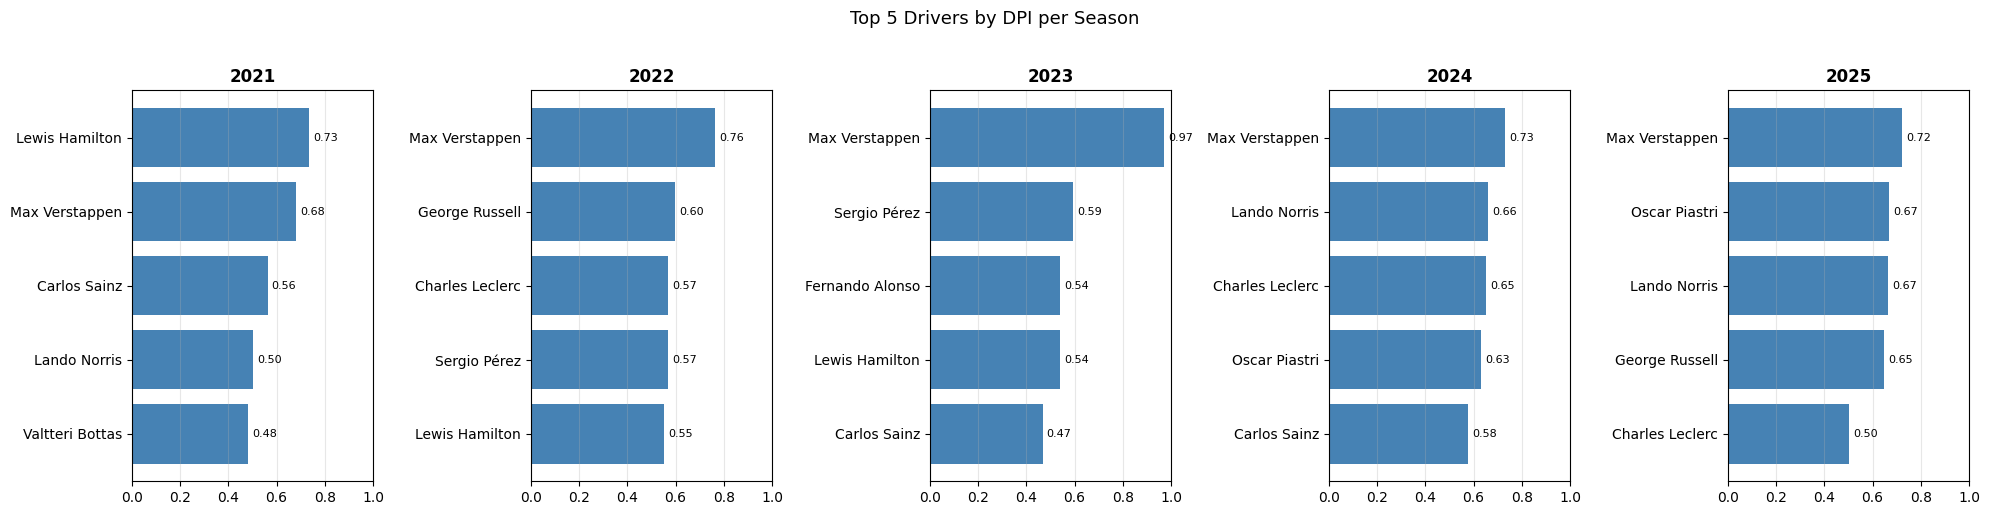

In [9]:
seasons = sorted(norm_df['season'].unique())
fig, axes = plt.subplots(1, len(seasons), figsize=(20, 5), sharey=False)

for i, season in enumerate(seasons):
    season_top = (
        norm_df[norm_df['season'] == season]
        .sort_values('DPI', ascending=False)
        .head(5)
        .reset_index(drop=True)
    )
    ax = axes[i]
    bars = ax.barh(season_top['driver_name'], season_top['DPI'],
                   color='steelblue')
    ax.invert_yaxis()
    ax.set_title(str(season), fontweight='bold')
    ax.set_xlim(0, 1)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top 5 Drivers by DPI per Season', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dpi_per_season.png', dpi=150, bbox_inches='tight')
plt.show()

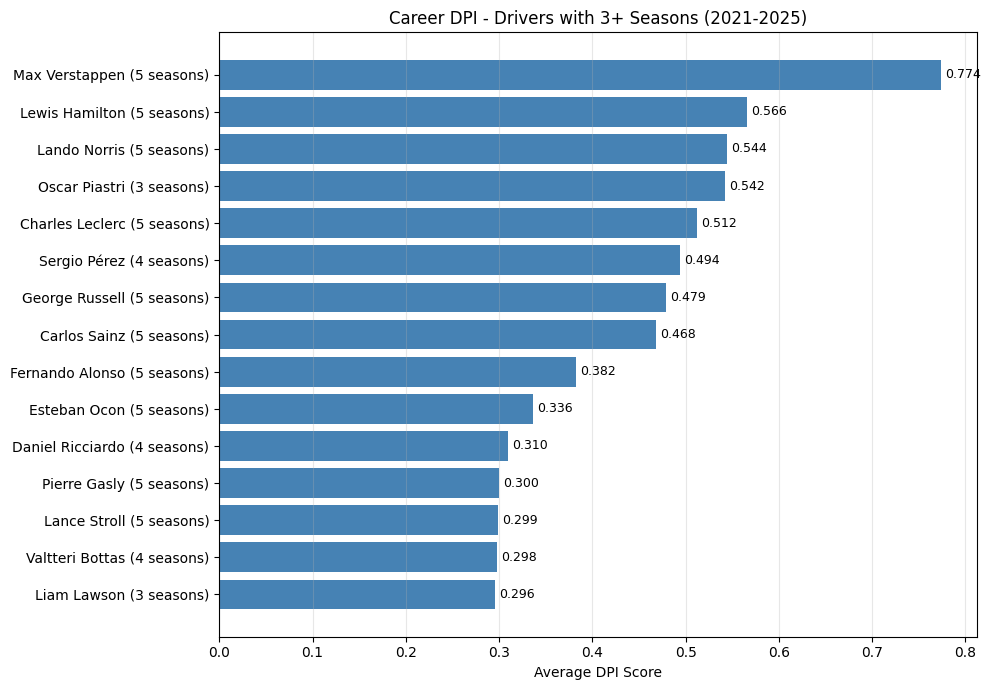

     driver_name  seasons  career_dpi
  Max Verstappen        5    0.773531
  Lewis Hamilton        5    0.565752
    Lando Norris        5    0.544343
   Oscar Piastri        3    0.542427
 Charles Leclerc        5    0.512228
    Sergio Pérez        4    0.493990
  George Russell        5    0.479127
    Carlos Sainz        5    0.468216
 Fernando Alonso        5    0.382272
    Esteban Ocon        5    0.336210
Daniel Ricciardo        4    0.309920
    Pierre Gasly        5    0.299743
    Lance Stroll        5    0.299287
 Valtteri Bottas        4    0.298122
     Liam Lawson        3    0.295620


In [10]:
career = (
    norm_df.groupby('driver_name')
    .agg(career_dpi=('DPI', 'mean'), seasons=('season', 'count'))
    .reset_index()
    .query('seasons >= 3')
    .sort_values('career_dpi', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    career['driver_name'] + ' (' + career['seasons'].astype(str) + ' seasons)',
    career['career_dpi'],
    color='steelblue'
)
ax.invert_yaxis()
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_title('Career DPI - Drivers with 3+ Seasons (2021-2025)')
ax.set_xlabel('Average DPI Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'career_dpi.png', dpi=150)
plt.show()

print(career[['driver_name', 'seasons', 'career_dpi']].to_string(index=False))